# 01. AI Usage Feature EDA

**Goal:** decide which features are useful for predicting `AISelect`.

PDF flow: load → validate → missing/duplicate check → descriptive statistics → group comparison → correlation → statistical test.
All chart text uses simple English to avoid Korean font issues. The source CSV is never modified.

## 1. Load with Pandas and Polars

PDF의 Pandas·Polars 비교 흐름을 적용한다. 시간 비교는 현재 컴퓨터에서 한 번 실행한 참고값일 뿐 절대 성능 기준이 아니다.

In [1]:
from pathlib import Path
from time import perf_counter
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eda-cache")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import chi2_contingency, ttest_ind
from IPython.display import display

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("results.csv")
TARGET = "AISelect"
ID_COLUMN = "ResponseId"
TARGET_ORDER = ["Yes", "No, but I plan to soon", "No, and I don't plan to"]
TARGET_NAMES = {
    "Yes": "Using now",
    "No, but I plan to soon": "Plan to use",
    "No, and I don't plan to": "No plan to use",
}

pandas_start = perf_counter()
raw_df = pd.read_csv(DATA_PATH, na_values=["NA", ""], keep_default_na=True, low_memory=False)
pandas_seconds = perf_counter() - pandas_start

polars_start = perf_counter()
raw_pl = pl.scan_csv(
    DATA_PATH, null_values=["NA", ""], infer_schema_length=0
).collect()
polars_seconds = perf_counter() - polars_start

load_comparison = pd.DataFrame([
    {"Library": "Pandas", "Rows": len(raw_df), "Columns": raw_df.shape[1],
     "Seconds": pandas_seconds, "Memory MB": raw_df.memory_usage(deep=True).sum() / 1024**2},
    {"Library": "Polars", "Rows": raw_pl.height, "Columns": raw_pl.width,
     "Seconds": polars_seconds, "Memory MB": raw_pl.estimated_size("mb")},
])
assert raw_df.shape == raw_pl.shape == (65_437, 114)
display(load_comparison)

,Library,Rows,Columns,Seconds,Memory MB
0,Pandas,65437,114,1.1435,418.4441
1,Polars,65437,114,0.1214,139.0354


## 2. Apply confirmed column decisions

`df`는 탐색용 102개 컬럼, `model_df`는 누수·저가치·저관련 컬럼을 제외한 모델링 후보 57개 컬럼이다.

In [2]:
ADMIRATION_COLUMNS = [
    "LanguageAdmired", "DatabaseAdmired", "PlatformAdmired", "WebframeAdmired",
    "EmbeddedAdmired", "MiscTechAdmired", "ToolsTechAdmired",
    "NEWCollabToolsAdmired", "OfficeStackAsyncAdmired",
    "OfficeStackSyncAdmired", "AISearchDevAdmired",
]
DROP_COLUMNS = ["Check", *ADMIRATION_COLUMNS]
LEAKAGE_COLUMNS = [
    "AISearchDevHaveWorkedWith", "AISearchDevWantToWorkWith", "AISent", "AIComplex",
    "AIToolCurrently Using", "AIToolInterested in Using", "AIToolNot interested in Using",
    "AINextMuch more integrated", "AINextMore integrated", "AINextNo change",
    "AINextLess integrated", "AINextMuch less integrated", "AIThreat", "AIEthics",
    "AIBen", "AIAcc", "AIChallenges",
]
LOW_VALUE_COLUMNS = [
    "SurveyLength", "SurveyEase", "Currency", "CompTotal",
    "JobSatPoints_1", "JobSatPoints_4", "JobSatPoints_5", "JobSatPoints_6",
    "JobSatPoints_7", "JobSatPoints_8", "JobSatPoints_9",
    "JobSatPoints_10", "JobSatPoints_11",
]
WEAK_RELEVANCE_COLUMNS = [
    *[f"Knowledge_{i}" for i in range(1, 10)],
    *[f"Frequency_{i}" for i in range(1, 4)],
    "TimeSearching", "TimeAnswering", "JobSat",
]
MODEL_EXCLUDE_COLUMNS = LEAKAGE_COLUMNS + LOW_VALUE_COLUMNS + WEAK_RELEVANCE_COLUMNS

df = raw_df.drop(columns=DROP_COLUMNS).copy()
model_df = df.drop(columns=MODEL_EXCLUDE_COLUMNS).copy()
analysis_df = model_df.loc[model_df[TARGET].notna()].copy()

assert df.shape[1] == 102
assert model_df.shape[1] == 57
assert len(analysis_df) == 60_907
print(f"Exploration data: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Modeling data:    {model_df.shape[0]:,} rows x {model_df.shape[1]} columns")
print(f"Valid target:     {analysis_df.shape[0]:,} rows")

Exploration data: 65,437 rows x 102 columns
Modeling data:    65,437 rows x 57 columns
Valid target:     60,907 rows


## 3. Basic validation

PDF의 `info`, `describe`, 결측치·중복 확인을 현재 데이터에 적용한다.

In [3]:
print("Full duplicate rows:", raw_df.duplicated().sum())
print("Duplicate ResponseId:", raw_df[ID_COLUMN].duplicated().sum())
print("Unique ResponseId:", raw_df[ID_COLUMN].nunique())

target_counts = raw_df[TARGET].value_counts(dropna=False)
target_summary = pd.DataFrame({
    "Target class": [TARGET_NAMES.get(value, "Missing") for value in target_counts.index],
    "Count": target_counts.values,
    "Percent of all rows": (target_counts.values / len(raw_df) * 100).round(2),
})
display(target_summary)

audit = pd.DataFrame({
    "Dtype": model_df.dtypes.astype(str),
    "Missing count": model_df.isna().sum(),
    "Missing %": model_df.isna().mean().mul(100).round(2),
    "Unique": model_df.nunique(dropna=True),
}).sort_values("Missing %", ascending=False)
display(audit)

Full duplicate rows: 0
Duplicate ResponseId: 0
Unique ResponseId: 65437


,Target class,Count,Percent of all rows
0,Using now,37662,57.5500
1,No plan to use,14837,22.6700
2,Plan to use,8408,12.8500
3,Missing,4530,6.9200


,Dtype,Missing count,Missing %,Unique
EmbeddedWantToWorkWith,object,47837,73.1000,1471
EmbeddedHaveWorkedWith,object,43223,66.0500,1630
ConvertedCompYearly,float64,42002,64.1900,6113
ProfessionalTech,object,37673,57.5700,514
Frustration,object,37186,56.8300,954
ProfessionalCloud,object,36946,56.4600,3
ProfessionalQuestion,object,36630,55.9800,9
Industry,object,36579,55.9000,15
WorkExp,float64,35779,54.6800,51
ICorPM,object,35636,54.4600,2


## 4. Statistical helper functions

카이제곱 검정은 관계 존재 여부, corrected Cramer's V는 관계 강도를 확인한다.
Correlation ratio(eta)는 범주형 타겟과 수치형 변수의 관계 강도를 0~1로 표현한다.

In [4]:
FEATURE_NAMES = {
    "MainBranch": "Developer profile", "Age": "Age group",
    "Employment": "Employment status", "RemoteWork": "Work location",
    "EdLevel": "Education level", "DevType": "Developer role",
    "Country": "Country", "Industry": "Industry",
    "ProfessionalCloud": "Cloud environment",
}

def collapse_rare(series: pd.Series, min_count: int = 200) -> pd.Series:
    values = series.fillna("Missing").astype(str)
    counts = values.value_counts()
    return values.where(values.isin(counts[counts >= min_count].index), "Other")

def corrected_cramers_v(table: pd.DataFrame) -> float:
    observed = table.to_numpy(dtype=float)
    n = observed.sum()
    if n <= 1 or min(observed.shape) < 2:
        return 0.0
    chi2, _, _, _ = chi2_contingency(observed)
    phi2 = chi2 / n
    rows, cols = observed.shape
    phi2 = max(0.0, phi2 - ((cols - 1) * (rows - 1)) / (n - 1))
    rows = rows - ((rows - 1) ** 2) / (n - 1)
    cols = cols - ((cols - 1) ** 2) / (n - 1)
    denominator = min(rows - 1, cols - 1)
    return float(np.sqrt(phi2 / denominator)) if denominator > 0 else 0.0

def correlation_ratio(categories: pd.Series, values: pd.Series) -> float:
    valid = categories.notna() & values.notna()
    categories = categories.loc[valid]
    values = values.loc[valid].astype(float)
    if values.empty or values.nunique() <= 1:
        return 0.0
    grand_mean = values.mean()
    between = sum(
        len(group) * (group.mean() - grand_mean) ** 2
        for _, group in values.groupby(categories)
    )
    total = ((values - grand_mean) ** 2).sum()
    return float(np.sqrt(between / total)) if total > 0 else 0.0

def to_years(value):
    if pd.isna(value):
        return np.nan
    if value == "Less than 1 year":
        return 0.5
    if value == "More than 50 years":
        return 51.0
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

## 5. Categorical features: groupby, pivot, chi-square

집단 크기가 200명 미만인 희소 범주는 `Other`로 묶는다. p-value와 함께 Cramer's V를 확인한다.

In [5]:
CATEGORICAL_FEATURES = [
    "MainBranch", "Age", "Employment", "RemoteWork", "EdLevel",
    "DevType", "Country", "Industry", "ProfessionalCloud",
]
categorical_rows = []
category_tables = {}

for column in CATEGORICAL_FEATURES:
    feature = collapse_rare(analysis_df[column], min_count=200)
    table = pd.crosstab(feature, analysis_df[TARGET]).reindex(columns=TARGET_ORDER, fill_value=0)
    chi2, p_value, _, _ = chi2_contingency(table)
    rates = table.div(table.sum(axis=1), axis=0).mul(100).rename(columns=TARGET_NAMES)
    rates.insert(0, "Count", table.sum(axis=1))
    category_tables[column] = rates.sort_values("Count", ascending=False)
    categorical_rows.append({
        "Feature": FEATURE_NAMES[column],
        "Source column": column,
        "Levels used": feature.nunique(),
        "Missing %": analysis_df[column].isna().mean() * 100,
        "Cramer's V": corrected_cramers_v(table),
        "Chi-square p-value": p_value,
        "Significant at 0.05": p_value < 0.05,
    })

categorical_results = pd.DataFrame(categorical_rows).sort_values("Cramer's V", ascending=False)
display(categorical_results)

for column in CATEGORICAL_FEATURES:
    print(f"\n--- {FEATURE_NAMES[column]} ({column}) ---")
    display(category_tables[column].head(20))

,Feature,Source column,Levels used,Missing %,Cramer's V,Chi-square p-value,Significant at 0.05
6,Country,Country,49,4.0455,0.1509,0.0000,True
5,Developer role,DevType,31,4.5857,0.1288,0.0000,True
1,Age group,Age,8,0.0000,0.1210,0.0000,True
2,Employment status,Employment,20,0.0000,0.0858,0.0000,True
4,Education level,EdLevel,9,3.3018,0.0835,0.0000,True
0,Developer profile,MainBranch,5,0.0000,0.0778,0.0000,True
8,Cloud environment,ProfessionalCloud,4,53.2221,0.0651,0.0000,True
7,Industry,Industry,16,52.6196,0.0456,0.0000,True
3,Work location,RemoteWork,4,16.1016,0.0348,0.0000,True



--- Developer profile (MainBranch) ---


AISelect,Count,Using now,Plan to use,No plan to use
MainBranch,,,,
I am a developer by profession,46853,63.2574,13.3524,23.3902
"I am not primarily a developer, but I write code sometimes as part of my work/studies",6075,57.5473,15.2757,27.1770
I am learning to code,3444,66.2021,17.2764,16.5215
I code primarily as a hobby,3118,52.2130,9.7498,38.0372
"I used to be a developer by profession, but no longer am",1417,43.7544,22.9358,33.3098



--- Age group (Age) ---


AISelect,Count,Using now,Plan to use,No plan to use
Age,,,,
25-34 years old,22160,65.5686,12.9648,21.4666
35-44 years old,14124,57.9439,16.1427,25.9133
18-24 years old,12749,70.3977,8.7536,20.8487
45-54 years old,6002,52.6158,19.3935,27.9907
55-64 years old,2485,40.8853,22.1328,36.9819
Under 18 years old,2366,60.6932,9.9324,29.3745
65 years or older,744,32.2581,20.4301,47.3118
Prefer not to say,277,44.4043,13.7184,41.8773


...

AISelect,Count,Using now,Plan to use,No plan to use
Country,,,,
United States of America,11001,54.2496,13.3806,32.3698
Other,5245,68.5987,14.7569,16.6444
Germany,4911,57.0963,12.6451,30.2586
India,4161,67.9404,21.5333,10.5263
United Kingdom of Great Britain and Northern Ireland,3209,50.7012,13.0259,36.2730
Ukraine,2668,72.3388,14.5802,13.0810
Missing,2464,79.4643,11.3231,9.2127
France,2094,54.2025,11.4613,34.3362
Canada,2084,58.2054,13.3397,28.4549



--- Industry (Industry) ---


AISelect,Count,Using now,Plan to use,No plan to use
Industry,,,,
Missing,32049,61.1720,13.5262,25.3019
Software Development,11918,65.5479,13.3412,21.1109
Other:,3077,59.7660,12.8697,27.3643
Fintech,1641,65.5088,15.1737,19.3175
"Internet, Telecomm or Information Services",1629,61.7557,14.7944,23.4500
Banking/Financial Services,1371,56.9657,19.3290,23.7053
Healthcare,1277,64.0564,13.1558,22.7878
Manufacturing,1265,57.8656,16.2055,25.9289
Retail and Consumer Services,1264,65.9810,13.0538,20.9652



--- Cloud environment (ProfessionalCloud) ---


AISelect,Count,Using now,Plan to use,No plan to use
ProfessionalCloud,,,,
Missing,32416,61.1488,13.5766,25.2746
Hybrid (on-prem and cloud),13230,60.4686,15.8050,23.7264
Cloud only (single or multi-cloud),11256,69.0121,11.8426,19.1453
On-prem,4005,51.7353,14.5568,33.7079


## 6. Numeric features: describe, IQR, correlation

경력 특수값을 숫자로 변환한다. 보수는 왜도가 크므로 원본 이상치를 확인하고 모델 비교에는 로그값을 사용한다.

In [6]:
numeric_df = pd.DataFrame(index=analysis_df.index)
numeric_df["Coding years"] = analysis_df["YearsCode"].map(to_years)
numeric_df["Professional coding years"] = analysis_df["YearsCodePro"].map(to_years)
numeric_df["Work experience"] = pd.to_numeric(analysis_df["WorkExp"], errors="coerce")
salary = pd.to_numeric(analysis_df["ConvertedCompYearly"], errors="coerce")
numeric_df["Annual compensation USD"] = salary
numeric_df["Annual compensation log"] = np.log1p(salary.where(salary >= 0))

describe_table = numeric_df.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T
describe_table["skew"] = numeric_df.skew()
describe_table["kurtosis"] = numeric_df.kurt()
display(describe_table)

iqr_rows = []
for column in numeric_df.columns:
    clean = numeric_df[column].dropna()
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_rows.append({
        "Feature": column, "Q1": q1, "Q3": q3, "IQR": iqr,
        "Lower bound": lower, "Upper bound": upper,
        "Potential outliers": ((clean < lower) | (clean > upper)).sum(),
    })
iqr_summary = pd.DataFrame(iqr_rows)
display(iqr_summary)

pearson_corr = numeric_df.drop(columns="Annual compensation USD").corr(method="pearson")
spearman_corr = numeric_df.drop(columns="Annual compensation USD").corr(method="spearman")
print("Pearson correlation")
display(pearson_corr)
print("Spearman correlation")
display(spearman_corr)

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,kurtosis
Coding years,58410.0000,14.2749,10.6749,0.5000,1.0000,6.0000,11.0000,20.0000,45.0000,51.0000,1.1824,0.8745
Professional coding years,50298.0000,10.2747,9.0991,0.5000,0.5000,3.0000,8.0000,15.0000,40.0000,51.0000,1.3378,1.5881
Work experience,29658.0000,11.4670,9.1687,0.0000,1.0000,4.0000,9.0000,16.0000,40.0000,50.0000,1.2417,1.3586
Annual compensation USD,23435.0000,86155.2873,186756.9731,1.0000,207.6800,32712.0000,65000.0000,107971.5000,393751.0600,16256603.0000,52.9217,3950.7774
Annual compensation log,23435.0000,10.7859,1.4029,0.6931,5.3408,10.3955,11.0822,11.5896,12.8834,16.6040,-2.2648,8.6564


,Feature,Q1,Q3,IQR,Lower bound,Upper bound,Potential outliers
0,Coding years,6.0000,20.0000,14.0000,-15.0000,41.0000,1489
1,Professional coding years,3.0000,15.0000,12.0000,-15.0000,33.0000,1400
2,Work experience,4.0000,16.0000,12.0000,-14.0000,34.0000,873
3,Annual compensation USD,32712.0000,107971.5000,75259.5000,-80177.2500,220860.7500,978
4,Annual compensation log,10.3955,11.5896,1.1941,8.6044,13.3808,1723


Pearson correlation


,Coding years,Professional coding years,Work experience,Annual compensation log
Coding years,1.0000,0.9212,0.8661,0.3447
Professional coding years,0.9212,1.0000,0.9284,0.3260
Work experience,0.8661,0.9284,1.0000,0.3256
Annual compensation log,0.3447,0.3260,0.3256,1.0000


Spearman correlation


,Coding years,Professional coding years,Work experience,Annual compensation log
Coding years,1.0000,0.8975,0.8363,0.4719
Professional coding years,0.8975,1.0000,0.9286,0.4778
Work experience,0.8363,0.9286,1.0000,0.4824
Annual compensation log,0.4719,0.4778,0.4824,1.0000


## 7. Numeric features vs target: eta and Welch t-test

3개 타겟 집단 차이는 eta로 비교한다. PDF의 t-test는 `Using now`와 나머지 응답자를 합친 `Not using now` 두 집단으로 수행한다.
표본이 크므로 p-value만 보지 않고 평균·중앙값과 eta를 함께 판단한다.

In [7]:
numeric_target_rows = []
for column in ["Coding years", "Professional coding years", "Work experience", "Annual compensation log"]:
    using = numeric_df.loc[analysis_df[TARGET] == "Yes", column].dropna()
    not_using = numeric_df.loc[analysis_df[TARGET] != "Yes", column].dropna()
    statistic, p_value = ttest_ind(using, not_using, equal_var=False)
    numeric_target_rows.append({
        "Feature": column,
        "Eta": correlation_ratio(analysis_df[TARGET], numeric_df[column]),
        "Using mean": using.mean(),
        "Not using mean": not_using.mean(),
        "Using median": using.median(),
        "Not using median": not_using.median(),
        "Welch t": statistic,
        "p-value": p_value,
        "Significant at 0.05": p_value < 0.05,
    })
numeric_target_results = pd.DataFrame(numeric_target_rows).sort_values("Eta", ascending=False)
display(numeric_target_results)

,Feature,Eta,Using mean,Not using mean,Using median,Not using median,Welch t,p-value,Significant at 0.05
0,Coding years,0.1722,12.8257,16.5491,10.0000,14.0000,-40.1713,0.0000,True
1,Professional coding years,0.1589,9.1410,12.1183,6.0000,10.0000,-34.6880,0.0000,True
2,Work experience,0.1322,10.5303,13.0311,8.0000,10.0000,-22.2355,0.0000,True
3,Annual compensation log,0.1057,10.6889,10.9524,11.0322,11.1844,-14.4299,0.0000,True


## 8. Multi-select technology choices

다중응답은 선택지별 0/1 값으로 바꿔 타겟과의 Cramer's V를 계산한다. 각 컬럼의 상위 10개 선택지만 확인한다.

In [8]:
MULTI_COLUMNS = [
    column for column in model_df.columns
    if column not in {TARGET, ID_COLUMN}
    and model_df[column].dropna().astype(str).str.contains(";", regex=False).any()
]
multi_rows = []
for column in MULTI_COLUMNS:
    choices = analysis_df[column].dropna().astype(str).str.split(";").explode().str.strip()
    top_choices = choices[choices.ne("")].value_counts().head(10)
    selected_sets = analysis_df[column].fillna("").astype(str).map(
        lambda value: {item.strip() for item in value.split(";") if item.strip()}
    )
    for choice in top_choices.index:
        selected = selected_sets.map(lambda values: choice in values)
        table = pd.crosstab(selected, analysis_df[TARGET])
        multi_rows.append({
            "Source column": column,
            "Choice": choice,
            "Selected count": selected.sum(),
            "Selected %": selected.mean() * 100,
            "Cramer's V": corrected_cramers_v(table),
        })
multi_results = pd.DataFrame(multi_rows).sort_values("Cramer's V", ascending=False)
display(multi_results.head(50))

,Source column,Choice,Selected count,Selected %,Cramer's V
34,LearnCodeOnline,AI,17704,29.0673,0.3733
40,TechDoc,AI-powered search/dev tool (free),11978,19.6660,0.2701
47,BuyNewTool,Ask a generative AI tool,8276,13.5879,0.2372
41,TechDoc,AI-powered search/dev tool (paid),5350,8.7839,0.2245
309,ProfessionalTech,AI-assisted technology tool(s),8994,14.7668,0.1633
19,LearnCode,Online Courses or Certification,29297,48.1012,0.1516
31,LearnCodeOnline,Video-based Online Courses,23930,39.2894,0.1369
132,WebframeWantToWorkWith,Next.js,8309,13.6421,0.1328
121,WebframeHaveWorkedWith,React,18763,30.8060,0.1288
123,WebframeHaveWorkedWith,Next.js,8463,13.8950,0.1286


## 9. PDF-required static EDA figure

한 화면에서 타겟 분포, 결측률, 집단별 수치 분포, 수치형 상관관계를 확인한다. 모든 문구는 영어로 표시한다.

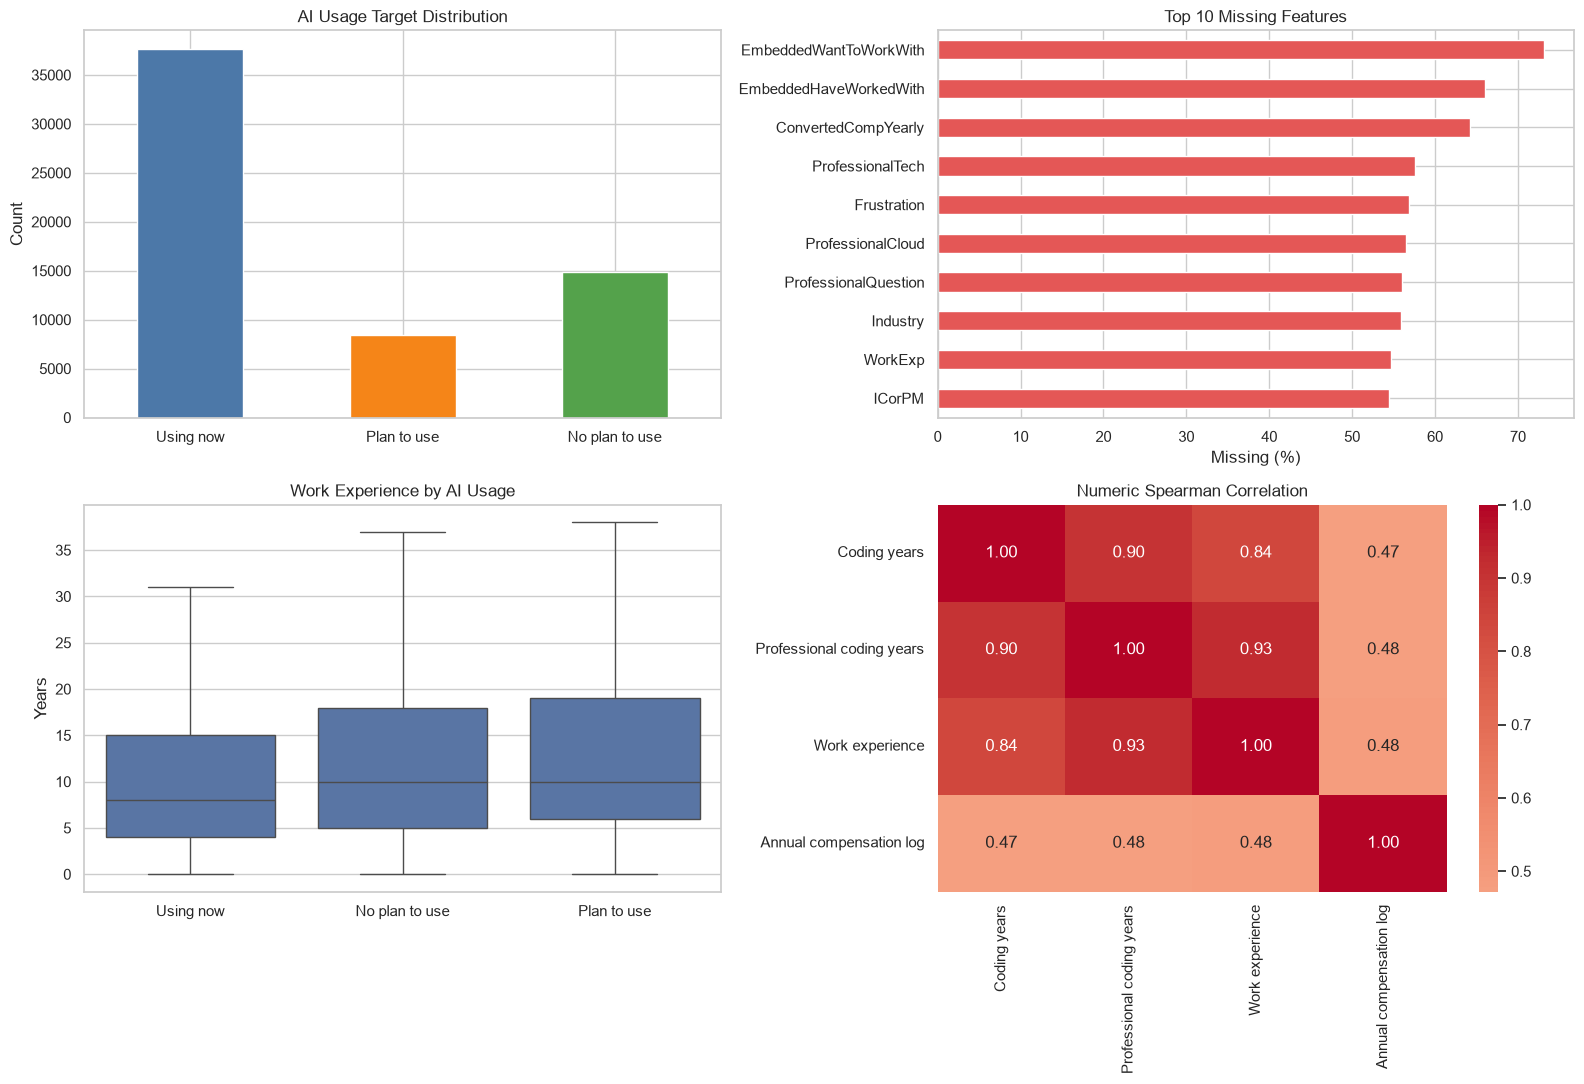

In [9]:
plot_df = numeric_df.assign(Target=analysis_df[TARGET].map(TARGET_NAMES))
target_plot = analysis_df[TARGET].map(TARGET_NAMES).value_counts().reindex(TARGET_NAMES.values())
top_missing = model_df.drop(columns=[TARGET, ID_COLUMN]).isna().mean().mul(100).nlargest(10).sort_values()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
target_plot.plot.bar(ax=axes[0, 0], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0, 0].set(title="AI Usage Target Distribution", xlabel="", ylabel="Count")
axes[0, 0].tick_params(axis="x", rotation=0)

top_missing.plot.barh(ax=axes[0, 1], color="#E45756")
axes[0, 1].set(title="Top 10 Missing Features", xlabel="Missing (%)", ylabel="")

sns.boxplot(data=plot_df, x="Target", y="Work experience", ax=axes[1, 0], showfliers=False)
axes[1, 0].set(title="Work Experience by AI Usage", xlabel="", ylabel="Years")

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1, 1])
axes[1, 1].set(title="Numeric Spearman Correlation")
plt.tight_layout()
plt.show()

## 10. PDF-required interactive chart

연령대별 타겟 비율을 Plotly 누적 막대로 확인하고 HTML로 저장한다.

In [10]:
age_table = pd.crosstab(analysis_df["Age"], analysis_df[TARGET], normalize="index").mul(100)
age_long = age_table.reindex(columns=TARGET_ORDER, fill_value=0).rename(columns=TARGET_NAMES).reset_index().melt(
    id_vars="Age", var_name="AI usage", value_name="Percent"
)
fig = px.bar(
    age_long, x="Age", y="Percent", color="AI usage",
    barmode="stack", title="AI Usage by Age Group",
    category_orders={"AI usage": list(TARGET_NAMES.values())},
)
fig.update_layout(xaxis_title="Age group", yaxis_title="Percent")
fig.show()
fig.write_html("ai_usage_by_age.html")
print("Saved: ai_usage_by_age.html")

Saved: ai_usage_by_age.html


## 11. Leakage confirmation

탐색용으로 보존한 AI 문항은 값의 존재만으로 타겟을 알려주므로 모델 입력에는 사용하지 않는다.

In [11]:
leakage_rows = []
for column in ["AIBen", "AIAcc", "AIChallenges"]:
    for target_value in TARGET_ORDER:
        group = df.loc[df[TARGET] == target_value, column]
        leakage_rows.append({
            "Feature": column,
            "Target class": TARGET_NAMES[target_value],
            "Value available %": group.notna().mean() * 100,
        })
leakage_check = pd.DataFrame(leakage_rows).pivot(
    index="Feature", columns="Target class", values="Value available %"
)
display(leakage_check)

Target class,No plan to use,Plan to use,Using now
Feature,,,
AIAcc,0.0000,0.0000,99.0441
AIBen,0.0000,0.0000,97.9608
AIChallenges,0.0000,81.7079,81.4110


## 12. Decision tables

판단은 아래 세 표만 보면 된다.

1. `categorical_results`: 범주형 관계 강도와 카이제곱 결과
2. `numeric_target_results`: 수치형 관계 강도와 t-test 결과
3. `multi_results`: 기술 선택지별 관계 강도

Cramer's V와 eta가 낮다는 이유만으로 바로 삭제하지 않는다. 결측률, 해석 가능성, 다른 변수와의 중복을 함께 확인한다.

In [12]:
print("Categorical features")
display(categorical_results[[
    "Feature", "Source column", "Missing %", "Cramer's V",
    "Chi-square p-value", "Significant at 0.05",
]])
print("Numeric features")
display(numeric_target_results)
print("Top multi-select choices")
display(multi_results.head(30))

Categorical features


,Feature,Source column,Missing %,Cramer's V,Chi-square p-value,Significant at 0.05
6,Country,Country,4.0455,0.1509,0.0000,True
5,Developer role,DevType,4.5857,0.1288,0.0000,True
1,Age group,Age,0.0000,0.1210,0.0000,True
2,Employment status,Employment,0.0000,0.0858,0.0000,True
4,Education level,EdLevel,3.3018,0.0835,0.0000,True
0,Developer profile,MainBranch,0.0000,0.0778,0.0000,True
8,Cloud environment,ProfessionalCloud,53.2221,0.0651,0.0000,True
7,Industry,Industry,52.6196,0.0456,0.0000,True
3,Work location,RemoteWork,16.1016,0.0348,0.0000,True


Numeric features


,Feature,Eta,Using mean,Not using mean,Using median,Not using median,Welch t,p-value,Significant at 0.05
0,Coding years,0.1722,12.8257,16.5491,10.0000,14.0000,-40.1713,0.0000,True
1,Professional coding years,0.1589,9.1410,12.1183,6.0000,10.0000,-34.6880,0.0000,True
2,Work experience,0.1322,10.5303,13.0311,8.0000,10.0000,-22.2355,0.0000,True
3,Annual compensation log,0.1057,10.6889,10.9524,11.0322,11.1844,-14.4299,0.0000,True


Top multi-select choices


,Source column,Choice,Selected count,Selected %,Cramer's V
34,LearnCodeOnline,AI,17704,29.0673,0.3733
40,TechDoc,AI-powered search/dev tool (free),11978,19.6660,0.2701
47,BuyNewTool,Ask a generative AI tool,8276,13.5879,0.2372
41,TechDoc,AI-powered search/dev tool (paid),5350,8.7839,0.2245
309,ProfessionalTech,AI-assisted technology tool(s),8994,14.7668,0.1633
19,LearnCode,Online Courses or Certification,29297,48.1012,0.1516
31,LearnCodeOnline,Video-based Online Courses,23930,39.2894,0.1369
132,WebframeWantToWorkWith,Next.js,8309,13.6421,0.1328
121,WebframeHaveWorkedWith,React,18763,30.8060,0.1288
123,WebframeHaveWorkedWith,Next.js,8463,13.8950,0.1286
